In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator, AutoMinorLocator



import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
# functions to import data

In [3]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

In [4]:
# functions to analyse

In [5]:
def calculate_deciles(data):
    # Flatten the data to 1D array for qcut
    flattened_data = data.flatten()
    # Calculate deciles using qcut
    deciles, bins = pd.qcut(flattened_data, qs, labels=False, retbins=True)
    # Reshape the result back to the original data shape
    return deciles.reshape(data.shape)

def calculate_monthly_deciles(ds, variable_name):
    # Get the shape of the data
    n_months = ds['time'].size
    lat_size = ds['lat'].size
    lon_size = ds['lon'].size
    
    # Create an empty array to hold the decile values
    deciles_array = np.empty((n_months, lat_size, lon_size))
    
    # Loop through each month and calculate deciles
    for i in range(n_months):
        month_data = ds[variable_name].isel(time=i).values
        deciles_array[i, :, :] = calculate_deciles(month_data)
    
    # Create a new DataArray for deciles
    dec = xr.DataArray(
        deciles_array,
        coords=[ds['time'], ds['lat'], ds['lon']],
        dims=['time', 'lat', 'lon']
    )
    
    return dec

In [6]:
def calculate_quantiles(data):
    # Flatten the data to 1D array for qcut
    flattened_data = data.flatten()
    # Calculate deciles using qcut
    deciles, bins = pd.qcut(flattened_data, qs, labels=False, retbins=True)
    # Reshape the result back to the original data shape
    return deciles.reshape(data.shape)


In [7]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi

# W_500

In [8]:
#compute the w500 cimatology and how it coolocates with sst climatology

In [9]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w = decode_time(fp).sel(lat = slice(25,-15), time = slice('1990', '2023'))


w = w.where(ocean_mask)

In [10]:
#comput clim and convert units
w_clim = w.sel(time = slice('1991', '2020')).groupby('time.month').mean() *(24*3600/100)


use this if actual w

In [11]:
w_sel = w.sel(time = slice('2014-07', '2016-07'))*(24*3600/100)
#extend periodically to cover july to jun over 2 years
w_by_qs = np.zeros((qs, 24))

for it in range(24):
    month_id = (it+7)%12
    s = w_sel.isel(time = it).w.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        w_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])
        


NameError: name 'qs' is not defined

use this if climatological w

In [ ]:
#extend periodically to cover july to jun over 2 years
w_by_qs = np.zeros((qs, 24))

for it in range(24):
    month_id = (it+7)%12
    s = w_clim.isel(month = month_id).w.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        w_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])
        


# Ocean Mask

# ERA5



In [11]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1980', '2023'))

sst = sst.where(ocean_mask)

#ocean_mask = ~sst.isel(time = 1).sst.isnull() # this mask for all tropics

In [12]:
fp = '/data/jmex/ERA5/monthly/era5_sst24.nc'
sst24 = xr.open_dataset(fp).sel(latitude = (slice(25, -15)))


#change the longitude defintion to 0-360
sst24 = sst24.rename({'latitude':'lat', 'longitude':'lon'})
sst24 = sst24.drop_vars(['number', 'expver'])


sst24 = sst24.rename({'date':'time'})
sst24['time'] = pd.to_datetime(sst24['time'].values.astype(str), format='%Y%m%d')

sst24 = sst24.where(ocean_mask)

In [13]:
sst = xr.concat([sst, sst24], dim = 'time')

In [14]:
sst_clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()
sst['anom'] = sst.sst.groupby('time.month') - sst_clim.sst

In [15]:
sst = sst.rolling(time = 3, center = True, min_periods = 1,).mean()

In [16]:
# calculate quantile of data on the climatology
qs = 20
sst_qs = calculate_quantiles(sst_clim.sst.values)





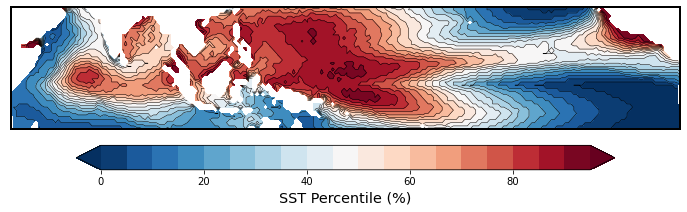

In [31]:
sst_aso_qs= np.mean(sst_qs[8:10,:,40:280], axis = 0)*5

# Define discrete color levels
levels = np.arange(0, 100, 5)  # Levels from 0 to 20

# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_qs, levels=levels, cmap='RdBu_r', extend='both')
contours = ax.contour(sst_aso_qs, levels=levels, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=False, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=levels[::4], pad=0.1)
cbar_ax.set_label('SST Percentile (%)', fontweight = 'normal')

#plt.title('ASO SST Percentile Distribution')
plt.gca().invert_yaxis()
plt.xticks([])
plt.yticks([])

plt.gca().spines[:].set_linewidth(2)


plt.show()

In [19]:
weights = np.cos(np.deg2rad(sst.lat))
sst['ocean_mean'] = sst.anom.weighted(weights).mean(['lat', 'lon'])

In [20]:
sst_sel = sst.sel(time = slice('2014-07', '2016-06'))
sst_by_qs = np.zeros((qs, sst_sel.time.shape[0]))

for it in range(len(sst_sel.time)):
    month_id = (it+7)%12
    s = sst_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        sst_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time = it).ocean_mean

NameError: name 'w_by_qs' is not defined

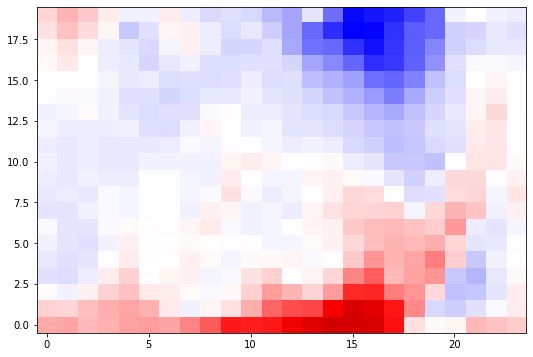

In [21]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs, cmap='seismic', vmin=-2, vmax=2,
    interpolation='none', origin='lower',
    aspect = .8
)



#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"


CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2015', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
sst_sel = sst.sel(time = slice('2022-07', '2024-06'))
sst_by_qs = np.zeros((qs, 24))

for it in range(len(sst_sel.time)):
    month_id = (it+7)%12 
    s = sst_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        sst_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time = it).ocean_mean 
        #take away comment if want to subtract the ocean mean anomaly

In [ ]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs, cmap='seismic', vmin=-2, vmax=2,
    interpolation='none', origin='lower',
    aspect = .8
)


#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"


CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2023', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
sst_sel = sst.sel(time = slice('2008-07', '2010-06'))
sst_by_qs = np.zeros((qs, 24))

for it in range(len(sst_sel.time)):
    month_id = (it+7)%12 
    s = sst_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        sst_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time = it).ocean_mean 
        #take away comment if want to subtract the ocean mean anomaly

In [ ]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs, cmap='seismic', vmin=-2, vmax=2,
    interpolation='none', origin='lower',
    aspect = .8
)


#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"


CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2009', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
sst_sel = sst.sel(time = slice('1996-07', '1998-06'))
sst_by_qs = np.zeros((qs, 24))

for it in range(len(sst_sel.time)):
    month_id = (it+7)%12 
    s = sst_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        sst_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time = it).ocean_mean 
        #take away comment if want to subtract the ocean mean anomaly

In [ ]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs, cmap='seismic', vmin=-2, vmax=2,
    interpolation='none', origin='lower',
    aspect = .8
)


#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"


CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('1997', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
sst_sel = sst.sel(time = slice('1981-07', '1983-06'))
sst_by_qs = np.zeros((qs, 24))

for it in range(len(sst_sel.time)):
    month_id = (it+7)%12 
    s = sst_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        sst_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time = it).ocean_mean 
        #take away comment if want to subtract the ocean mean anomaly

In [ ]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs, cmap='seismic', vmin=-2, vmax=2,
    interpolation='none', origin='lower',
    aspect = .8
)


#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"


CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('1982', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


# TP

In [ ]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp).sel(lat = slice(25,-15), time = slice('1980', '2023'))




In [ ]:
fp = '/data/jmex/ERA5/monthly/era5_tp2410.nc'
tp24 = xr.open_dataset(fp).sel(latitude = (slice(25, -15)))


#change the longitude defintion to 0-360
tp24 = tp24.rename({'latitude':'lat', 'longitude':'lon'})
tp24 = tp24.drop_vars(['number', 'expver'])


tp24 = tp24.rename({'date':'time'})
tp24['time'] = pd.to_datetime(tp24['time'].values.astype(str), format='%Y%m%d')

tp24['tp'] =tp24.tp*1000

In [ ]:
tp = xr.concat([tp, tp24], dim = 'time')

In [ ]:
tp = tp.where(ocean_mask)

In [ ]:
tp = tp.rolling(time = 3, center = True, min_periods = 1,).mean()

In [ ]:
tp_clim = tp.sel(time = slice('1991', '2020')).groupby('time.month').mean()
tp['anom'] = tp.tp.groupby('time.month') - tp_clim.tp

In [ ]:
weights = np.cos(np.deg2rad(tp.lat))
tp['ocean_mean'] = tp.anom.weighted(weights).mean(['lat', 'lon'])

In [ ]:
tp_sel = tp.sel(time = slice('2014-07', '2016-06'))
tp_by_qs = np.zeros((qs, tp_sel.time.shape[0]))

for it in range(len(tp_sel.time)):
    month_id = (it+7)%12
    s = tp_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])- tp_sel.isel(time = it).ocean_mean

In [ ]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2015', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
tp_sel = tp.sel(time = slice('2022-07', '2024-06'))
tp_by_qs = np.zeros((qs, tp_sel.time.shape[0]))

for it in range(len(tp_sel.time)):
    month_id = (it+7)%12
    s = tp_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])- tp_sel.isel(time = it).ocean_mean

In [ ]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2023', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [22]:
tp_sel = tp.sel(time = slice('2008-07', '2010-06'))
tp_by_qs = np.zeros((qs, tp_sel.time.shape[0]))

for it in range(len(tp_sel.time)):
    month_id = (it+7)%12
    s = tp_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])- tp_sel.isel(time = it).ocean_mean

NameError: name 'tp' is not defined

NameError: name 'tp_by_qs' is not defined

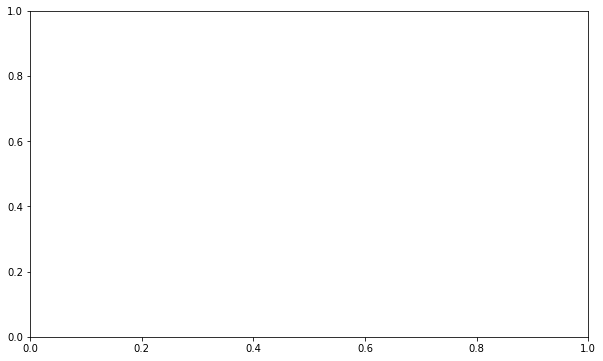

In [23]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2009', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [24]:
tp_sel = tp.sel(time = slice('1996-07', '1998-06'))
tp_by_qs = np.zeros((qs, tp_sel.time.shape[0]))

for it in range(len(tp_sel.time)):
    month_id = (it+7)%12
    s = tp_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])- tp_sel.isel(time = it).ocean_mean

NameError: name 'tp' is not defined

NameError: name 'tp_by_qs' is not defined

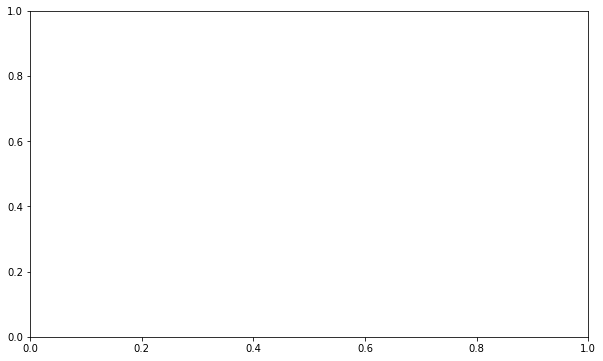

In [25]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('1997', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [26]:
tp_sel = tp.sel(time = slice('1981-07', '1983-06'))
tp_by_qs = np.zeros((qs, tp_sel.time.shape[0]))

for it in range(len(tp_sel.time)):
    month_id = (it+7)%12
    s = tp_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])- tp_sel.isel(time = it).ocean_mean

NameError: name 'tp' is not defined

NameError: name 'tp_by_qs' is not defined

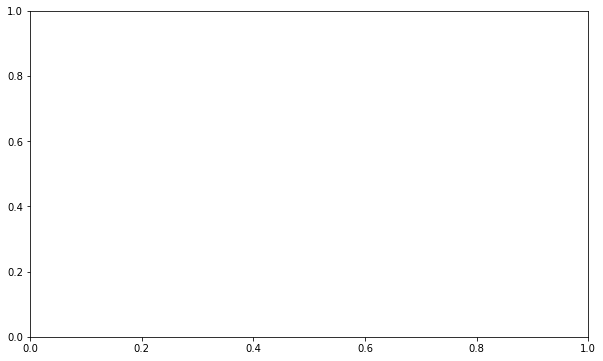

In [27]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('1982', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


## Maps of Anoouly over SST climatologies

## Compound

### SST

In [28]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1950', '2023'))

sst = sst.where(ocean_mask)

#ocean_mask = ~sst.isel(time = 1).sst.isnull() # this mask for all tropics

In [29]:
fp = '/data/jmex/ERA5/monthly/era5_sst24.nc'
sst24 = xr.open_dataset(fp).sel(latitude = (slice(25, -15)))


#change the longitude defintion to 0-360
sst24 = sst24.rename({'latitude':'lat', 'longitude':'lon'})
sst24 = sst24.drop_vars(['number', 'expver'])


sst24 = sst24.rename({'date':'time'})
sst24['time'] = pd.to_datetime(sst24['time'].values.astype(str), format='%Y%m%d')

sst24 = sst24.where(ocean_mask)

In [30]:
sst = xr.concat([sst, sst24], dim = 'time')

In [31]:
sst_clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()
sst['anom'] = sst.sst.groupby('time.month') - sst_clim.sst

In [32]:
weights = np.cos(np.deg2rad(sst.lat))
sst['ocean_mean'] = sst.anom.weighted(weights).mean(['lat', 'lon'])

In [33]:
sst = sst.rolling(time = 3, center = True, min_periods = 1,).mean()

In [34]:
# calculate quantile of data on the climatology
qs = 20
sst_qs = calculate_quantiles(sst_clim.sst.values)





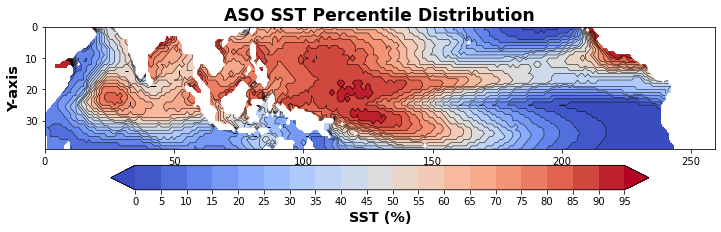

In [35]:
sst_aso_qs= sst_qs[9,:,40:300]*5

# Define discrete color levels
levels = np.arange(0, 100, 5)  # Levels from 0 to 20

# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_qs, levels=levels, cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels=levels, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=False, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=levels, pad=0.1)
cbar_ax.set_label('SST (%)')

plt.title('ASO SST Percentile Distribution')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

In [36]:
sst_aso_anom = sst.sel(time = '2023-09').anom - sst.sel(time = '2023-09').ocean_mean
sst_aso_anom = sst_aso_anom.values[0]

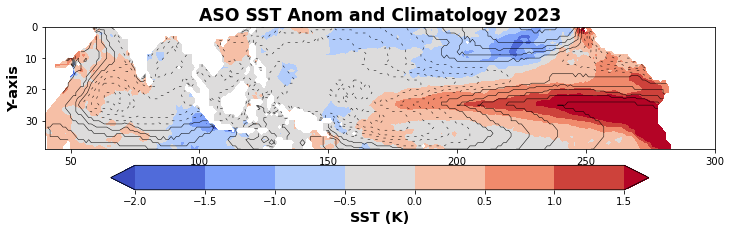

In [37]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_anom, levels=np.arange(-2,2,0.5),
                   cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels,
                      linestyles = linestyles, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=True, fontsize=8)



# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-2,2,0.5), pad=0.1)
cbar_ax.set_label('SST (K)')

plt.title('ASO SST Anom and Climatology 2023')
plt.xlabel('X-axis')
plt.xlim(40, 300)
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

In [38]:

event_list = ['1957-09', '1965-09', '1991-09', '1987-09', '1982-09', '1997-09', '2015-09']

In [39]:
sst_aso_anom_compound = np.zeros((len(event_list),40,360))

for i,e in enumerate(event_list):
    sst_aso_anom_e = sst.sel(time = e).anom -sst.sel(time = e).ocean_mean
    sst_aso_anom_compound[i] = sst_aso_anom_e.values[0]
    
sst_aso_anom_compound = np.mean(sst_aso_anom_compound, axis = 0)

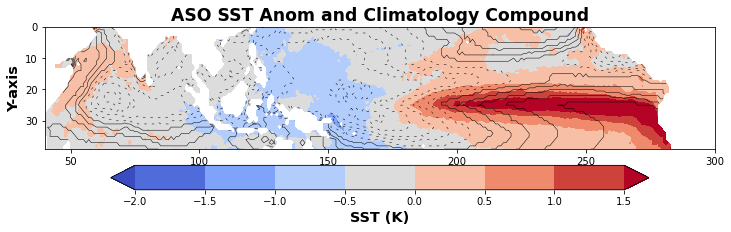

In [40]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_anom_compound, levels=np.arange(-2,2,0.5), cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels,
                      linestyles = linestyles, colors='black', linewidths=0.5)#plt.clabel(contours, inline=True, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-2,2,0.5), pad=0.1)
cbar_ax.set_label('SST (K)')

plt.title('ASO SST Anom and Climatology Compound')
plt.xlim(40, 300)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

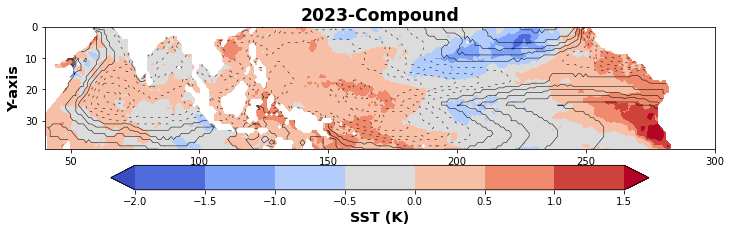

In [41]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_anom - sst_aso_anom_compound, levels=np.arange(-2,2,0.5), cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels,
                      linestyles = linestyles, colors='black', linewidths=0.5)#plt.clabel(contours, inline=True, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-2,2,0.5), pad=0.1)
cbar_ax.set_label('SST (K)')

plt.title('2023-Compound')
plt.xlim(40, 300)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

### tp

In [42]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp).sel(lat = slice(25,-15), time = slice('1950', '2023'))




In [43]:
fp = '/data/jmex/ERA5/monthly/era5_tp2410.nc'
tp24 = xr.open_dataset(fp).sel(latitude = (slice(25, -15)))


#change the longitude defintion to 0-360
tp24 = tp24.rename({'latitude':'lat', 'longitude':'lon'})
tp24 = tp24.drop_vars(['number', 'expver'])


tp24 = tp24.rename({'date':'time'})
tp24['time'] = pd.to_datetime(tp24['time'].values.astype(str), format='%Y%m%d')

tp24['tp'] =tp24.tp*1000

In [44]:
tp = xr.concat([tp, tp24], dim = 'time')

In [45]:
#required to make look same as sst
tp = tp.sortby('lat', ascending = False)

In [46]:
tp = tp.where(ocean_mask)

In [47]:
tp = tp.rolling(time = 3, center = True, min_periods = 1,).mean()

In [48]:
tp_clim = tp.sel(time = slice('1991', '2020')).groupby('time.month').mean()
tp['anom'] = tp.tp.groupby('time.month') - tp_clim.tp

In [49]:
weights = np.cos(np.deg2rad(tp.lat))
tp['ocean_mean'] = tp.anom.weighted(weights).mean(['lat', 'lon'])

In [50]:
tp_aso_anom = tp.sel(time = '2023-09').anom - tp.sel(time = '2023-09').ocean_mean
tp_aso_anom = tp_aso_anom.values[0]

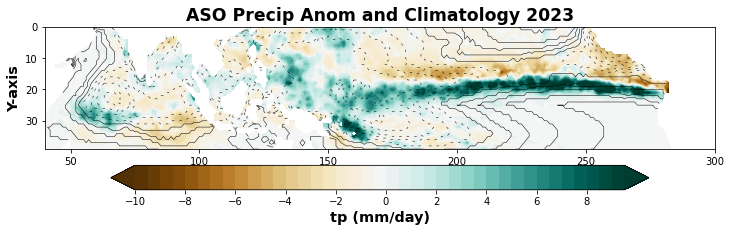

In [51]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(tp_aso_anom, levels=np.arange(-10,10,0.5), cmap='BrBG', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels, 
                      linestyles = linestyles, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=True, fontsize=8)
# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-10,10,2), pad=0.1)
cbar_ax.set_label('tp (mm/day)')

plt.title('ASO Precip Anom and Climatology 2023')
plt.xlabel('X-axis')
plt.xlim(40, 300)
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

In [52]:

event_list = ['1957-09', '1965-09', '1991-09', '1987-09', '1982-09', '1997-09', '2015-09']

In [53]:
tp_aso_anom_compound = np.zeros((len(event_list),40,360))

for i,e in enumerate(event_list):
    tp_aso_anom_e = tp.sel(time = e).anom -tp.sel(time = e).ocean_mean
    tp_aso_anom_compound[i] = tp_aso_anom_e.values[0]
    
tp_aso_anom_compound = np.mean(tp_aso_anom_compound, axis = 0)

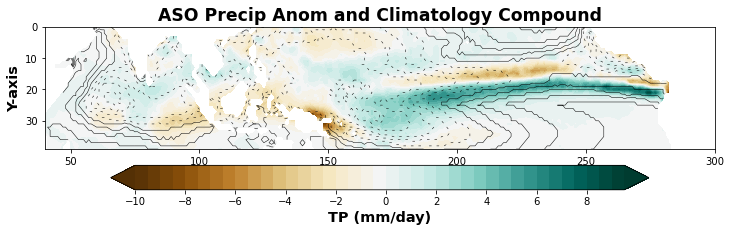

In [54]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(tp_aso_anom_compound, levels=np.arange(-10,10,0.5), cmap='BrBG', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels, 
                      linestyles = linestyles, colors='black', linewidths=0.5)#plt.clabel(contours, inline=True, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-10,10,2), pad=0.1)
cbar_ax.set_label('TP (mm/day)')

plt.title('ASO Precip Anom and Climatology Compound')
plt.xlim(40, 300)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

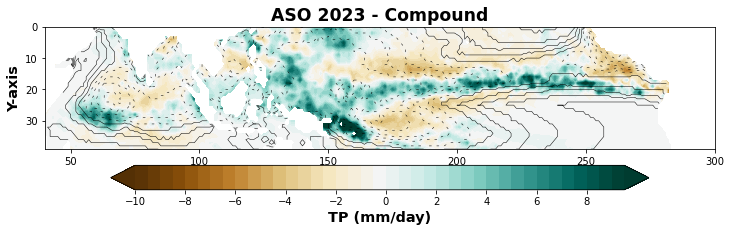

In [55]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(tp_aso_anom - tp_aso_anom_compound, levels=np.arange(-10,10,0.5), cmap='BrBG', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels, 
                      linestyles = linestyles, colors='black', linewidths=0.5)#plt.clabel(contours, inline=True, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-10,10,2), pad=0.1)
cbar_ax.set_label('TP (mm/day)')

plt.title('ASO 2023 - Compound')
plt.xlim(40, 300)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

## Compound

### SST

In [56]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1950', '2023'))

sst = sst.where(ocean_mask)

#ocean_mask = ~sst.isel(time = 1).sst.isnull() # this mask for all tropics

In [57]:
fp = '/data/jmex/ERA5/monthly/era5_sst24.nc'
sst24 = xr.open_dataset(fp).sel(latitude = (slice(25, -15)))


#change the longitude defintion to 0-360
sst24 = sst24.rename({'latitude':'lat', 'longitude':'lon'})
sst24 = sst24.drop_vars(['number', 'expver'])


sst24 = sst24.rename({'date':'time'})
sst24['time'] = pd.to_datetime(sst24['time'].values.astype(str), format='%Y%m%d')

sst24 = sst24.where(ocean_mask)

In [58]:
sst = xr.concat([sst, sst24], dim = 'time')

In [59]:
sst_clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()
sst['anom'] = sst.sst.groupby('time.month') - sst_clim.sst

In [60]:
sst = sst.rolling(time = 3, center = True, min_periods = 1,).mean()

In [61]:
# calculate quantile of data on the climatology
qs = 20
sst_qs = calculate_quantiles(sst_clim.sst.values)





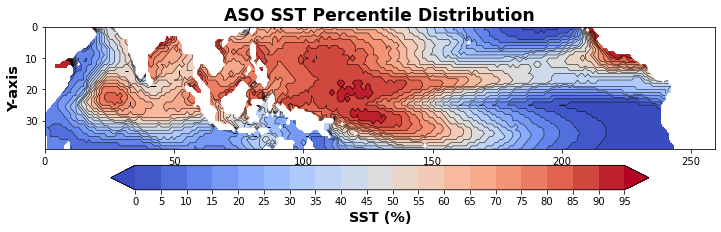

In [62]:
sst_aso_qs= sst_qs[9,:,40:300]*5

# Define discrete color levels
levels = np.arange(0, 100, 5)  # Levels from 0 to 20

# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_qs, levels=levels, cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels=levels, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=False, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=levels, pad=0.1)
cbar_ax.set_label('SST (%)')

plt.title('ASO SST Percentile Distribution')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

In [63]:
weights = np.cos(np.deg2rad(sst.lat))
sst['ocean_mean'] = sst.anom.weighted(weights).mean(['lat', 'lon'])

In [64]:
def compute_sst_by_quantiles(sst, start_time, end_time, sst_qs, qs):
    """
    Compute SST values based on quantiles for a given time slice.

    Parameters:
    - sst: xarray DataArray containing SST data.
    - start_time: str, start of the time slice (e.g., '1964-07').
    - end_time: str, end of the time slice (e.g., '1966-06').
    - sst_qs: quantile-based segmentation array.
    - qs: number of quantiles.

    Returns:
    - sst_by_qs: 2D numpy array of shape (qs, time_length), the processed SST values.
    """
    sst_sel = sst.sel(time=slice(start_time, end_time))
    time_length = len(sst_sel.time)
    sst_by_qs = np.zeros((qs, time_length))

    for it in range(time_length):
        month_id = (it + 7) % 12  # Offset month ID
        s = sst_sel.isel(time=it).anom.values

        for iq in range(qs):
            sst_by_qs[iq, it] = (
                np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time=it).ocean_mean
            )

    return sst_by_qs

def aggregate_sst_by_quantiles(sst, time_periods, sst_qs, qs):
    """
    Aggregate SST quantile computations over multiple time periods.

    Parameters:
    - sst: xarray DataArray containing SST data.
    - time_periods: list of tuples, each with (start_time, end_time).
    - sst_qs: quantile-based segmentation array.
    - qs: number of quantiles.

    Returns:
    - aggregated_sst_by_qs: 2D numpy array of the mean SST values across all periods.
    """
    all_sst_by_qs = []
    
    for start_time, end_time in time_periods:
        sst_by_qs = compute_sst_by_quantiles(sst, start_time, end_time, sst_qs, qs)
        all_sst_by_qs.append(sst_by_qs)
    
    aggregated_sst_by_qs = np.mean(all_sst_by_qs, axis=0)
    return aggregated_sst_by_qs


In [65]:
# Define your time periods
time_periods = [
   # ('1956-07', '1958-06'),
   # ('1964-07', '1966-06'),
    ('1990-07', '1992-06'),
   # ('1971-07', '1973-06'),
    ('1986-07', '1988-06'),
    ('1981-07', '1983-06'),
    ('1996-07', '1998-06'),
    ('2014-07', '2016-06'),
    # Add more periods as needed
]

# Compute aggregated SST by quantiles
sst_by_qs_compound = aggregate_sst_by_quantiles(sst, time_periods, sst_qs, qs)


In [66]:
sst_by_qs_diff = sst_by_qs-sst_by_qs_compound

NameError: name 'w_by_qs' is not defined

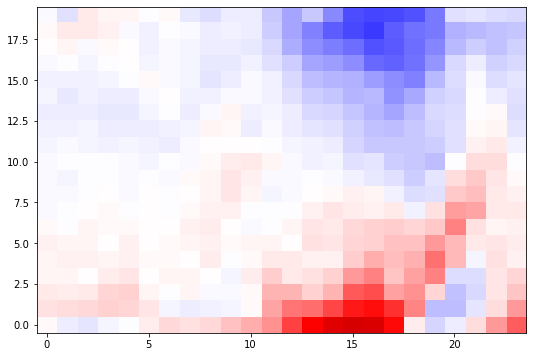

In [67]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs_compound, cmap='seismic', vmin=-2, vmax=2,
    interpolation='none', origin='lower',
    aspect = .8
)


#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"


CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('Compound', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


## Compound

# TP

In [170]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp).sel(lat = slice(25,-15), time = slice('1950', '2023'))




In [171]:
fp = '/data/jmex/ERA5/monthly/era5_tp2410.nc'
tp24 = xr.open_dataset(fp).sel(latitude = (slice(25, -15)))


#change the longitude defintion to 0-360
tp24 = tp24.rename({'latitude':'lat', 'longitude':'lon'})
tp24 = tp24.drop_vars(['number', 'expver'])


tp24 = tp24.rename({'date':'time'})
tp24['time'] = pd.to_datetime(tp24['time'].values.astype(str), format='%Y%m%d')

tp24['tp'] =tp24.tp*1000

In [172]:
tp = xr.concat([tp, tp24], dim = 'time')

In [173]:
tp = tp.where(ocean_mask)

In [174]:
tp = tp.rolling(time = 3, center = True, min_periods = 1,).mean()

In [175]:
tp_clim = tp.sel(time = slice('1991', '2020')).groupby('time.month').mean()
tp['anom'] = tp.tp.groupby('time.month') - tp_clim.tp

In [176]:
weights = np.cos(np.deg2rad(tp.lat))
tp['ocean_mean'] = tp.anom.weighted(weights).mean(['lat', 'lon'])

In [177]:
def compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time):
    """
    Compute `tp` values based on SST quantiles for a given time slice.

    Parameters:
    - tp: xarray DataArray containing the `tp` data.
    - sst_qs: quantile-based segmentation array derived from SST.
    - qs: number of quantiles.
    - start_time: str, start of the time slice (e.g., '2014-07').
    - end_time: str, end of the time slice (e.g., '2016-06').

    Returns:
    - tp_by_qs: 2D numpy array of shape (qs, time_length), the processed `tp` values.
    """
    tp_sel = tp.sel(time=slice(start_time, end_time))
    time_length = len(tp_sel.time)
    tp_by_qs = np.zeros((qs, time_length))

    for it in range(time_length):
        month_id = (it + 7) % 12  # Offset month ID
        s = tp_sel.isel(time=it).anom.values

        for iq in range(qs):
            tp_by_qs[iq, it] = (
                np.nanmean(s[sst_qs[month_id] == iq]) - tp_sel.isel(time=it).ocean_mean
            )

    return tp_by_qs

def aggregate_tp_by_quantiles(tp, sst_qs, qs, time_periods):
    """
    Aggregate `tp` quantile computations over multiple time periods.

    Parameters:
    - tp: xarray DataArray containing the `tp` data.
    - sst_qs: quantile-based segmentation array derived from SST.
    - qs: number of quantiles.
    - time_periods: list of tuples, each with (start_time, end_time).

    Returns:
    - aggregated_tp_by_qs: 2D numpy array of the mean `tp` values across all periods.
    """
    all_tp_by_qs = []
    
    for start_time, end_time in time_periods:
        tp_by_qs = compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time)
        all_tp_by_qs.append(tp_by_qs)
    
    aggregated_tp_by_qs = np.mean(all_tp_by_qs, axis=0)
    return aggregated_tp_by_qs


In [178]:
tp_sel = tp.sel(time = slice('2022-07', '2024-06'))
tp_by_qs = np.zeros((qs, tp_sel.time.shape[0]))

for it in range(len(tp_sel.time)):
    month_id = (it+7)%12
    s = tp_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])- tp_sel.isel(time = it).ocean_mean

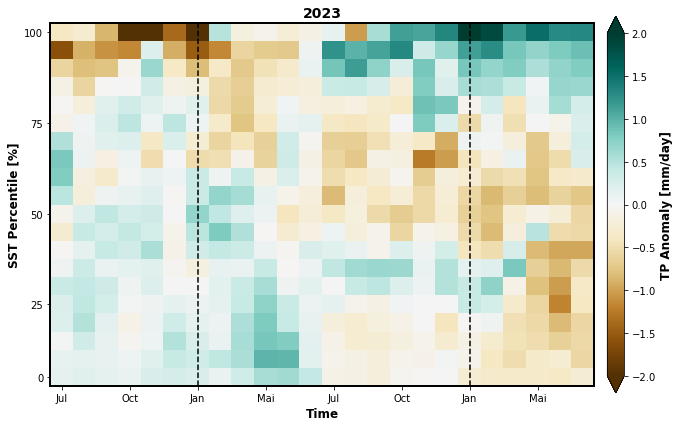

In [179]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2023', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [188]:
# Define your time periods
tp_time_periods = [
    ('1956-07', '1958-06'),
    ('1964-07', '1966-06'),
    ('1990-07', '1992-06'),
    ('1971-07', '1973-06'),
    ('1986-07', '1988-06'),
    ('1981-07', '1983-06'),
    ('1996-07', '1998-06'),
    ('2014-07', '2016-06'),
    # Add more periods as needed
]

# Compute aggregated `tp` by quantiles
tp_by_qs_compound = aggregate_tp_by_quantiles(tp, sst_qs, qs, tp_time_periods)


In [189]:
tp_by_qs_diff = tp_by_qs - tp_by_qs_compound

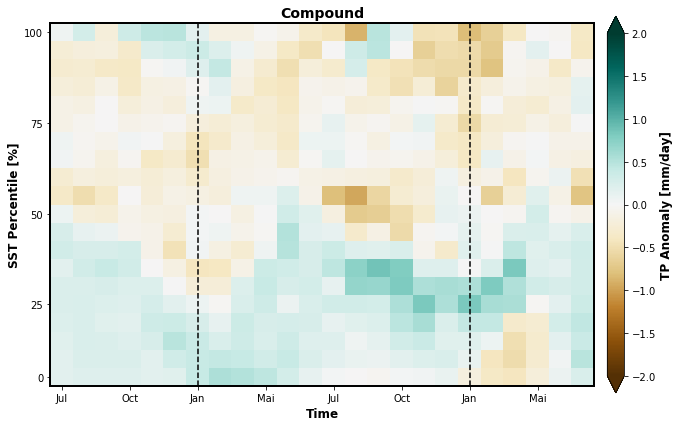

In [190]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs_compound, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('Compound', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


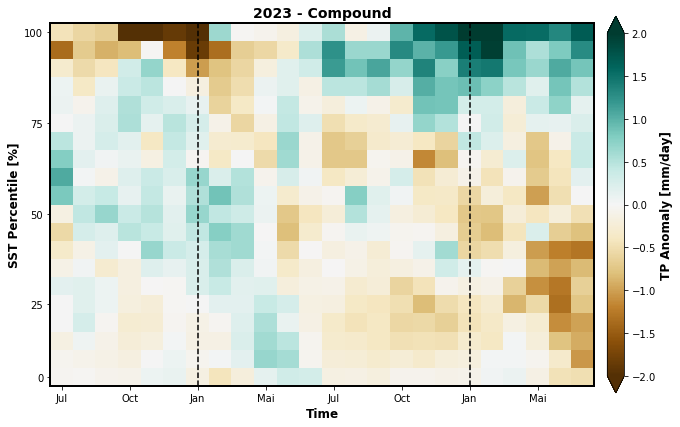

In [191]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs_diff, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2023 - Compound', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()
